In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, "/home/lilianae/projects/naf_clean")

parent_folder = str(Path.cwd().parents[0])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
from sigpy.mri import dcf

import scipy
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import sigpy as sp
import cupy as cp
import numpy as np


## My files
import save_data_helpers
from ksp_plot_helpers import plot_ksp_data_multichannel
import recon_functions
import recon_plot_helpers
import raw_data_utils
import coil_utils
from admm.utils_moco import golden_angle_coords_3d

## 1. Load data 

Load non-cartesian k-space data. It should be formatted as: (num_channels, num_slices, num_spokes, num_readouts).

In [2]:
ksp_512 = save_data_helpers.read_pickle('/home/lilianae/projects/naf_clean/load_data_clean/subject3_mid0283/patient3_mid0283_ksp_from_mdb_512_samples.pkl')
ksp_512 = np.transpose(ksp_512, (2, 0, 1, 3))
print(f'ksp_512.shape = {ksp_512.shape}')

ksp_512.shape = (15, 58, 2002, 512)


## 2. Crop k-space

For non-Cartesian data, crop k-space along the center most samples. Given a desired oshape (nz', ny', nx'), we will crop slice and spoke dimension along the central most samples. 

In [3]:
oshape = (12, 32, 32)
ksp_512_cropped = coil_utils.crop_kspace(ksp_data=ksp_512,
                              oshape=oshape)

Slices cropped from indices 23 to 35 
Samples cropped from indices 240 to 272
Cropped kspace shape = (15, 12, 2002, 32)


### 2a. Double-check k-space cropping

After our non-Cartesian k-space has been cropped, do a quick NUFFT recon to verify that we performed cropping correctly

In [4]:
ncoils, nslices, nspokes, nsamples = ksp_512_cropped.shape
img_shape = (nslices, nsamples, nsamples)
coord = golden_angle_coords_3d(img_shape=img_shape, num_spokes=nspokes, num_points=nsamples)
dcf_ksp = dcf.pipe_menon_dcf(coord, img_shape)
coil_images = sp.nufft_adjoint(ksp_512_cropped* dcf_ksp, coord)

PipeMenonDCF:   0%|          | 0/30 [00:00<?, ?it/s]

Show reconstructions

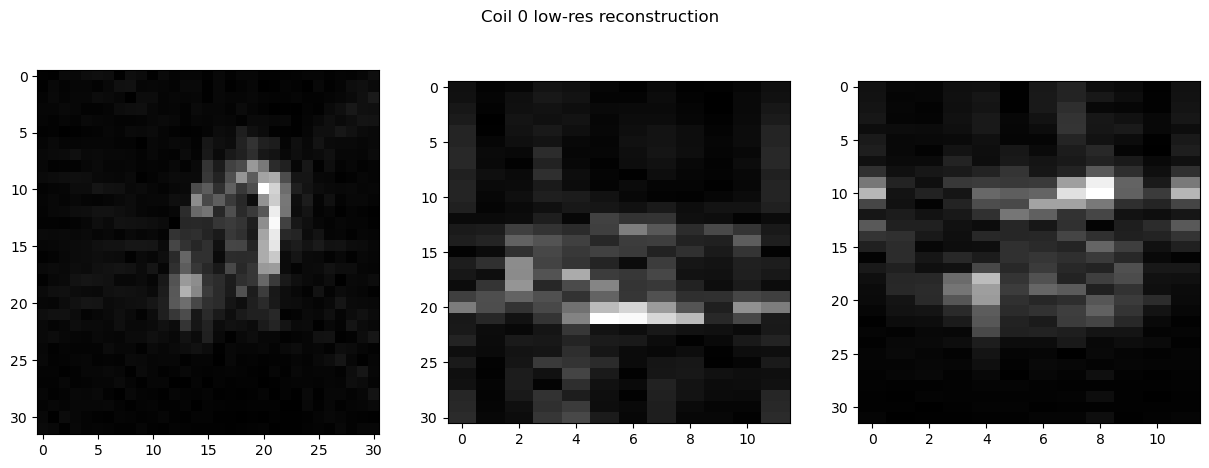

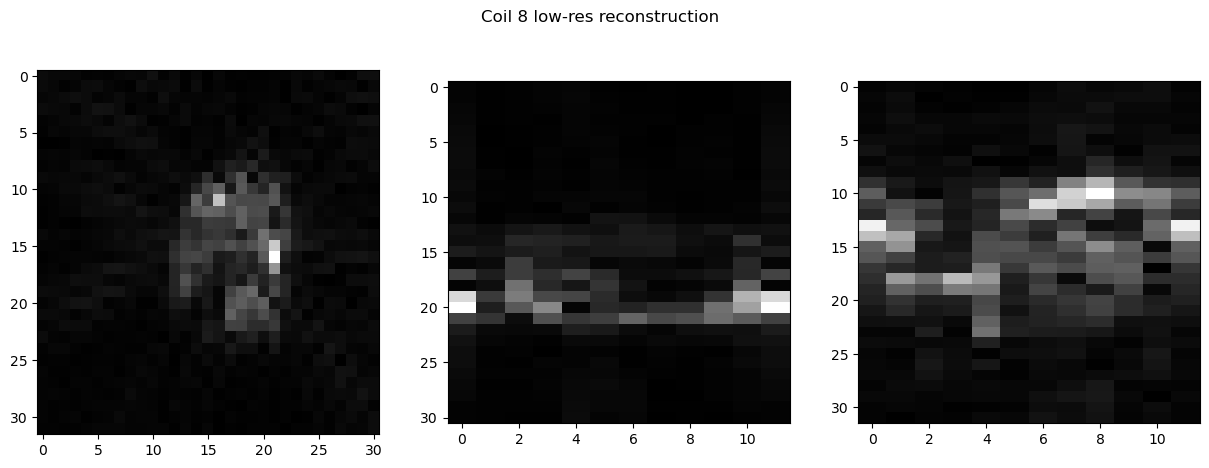

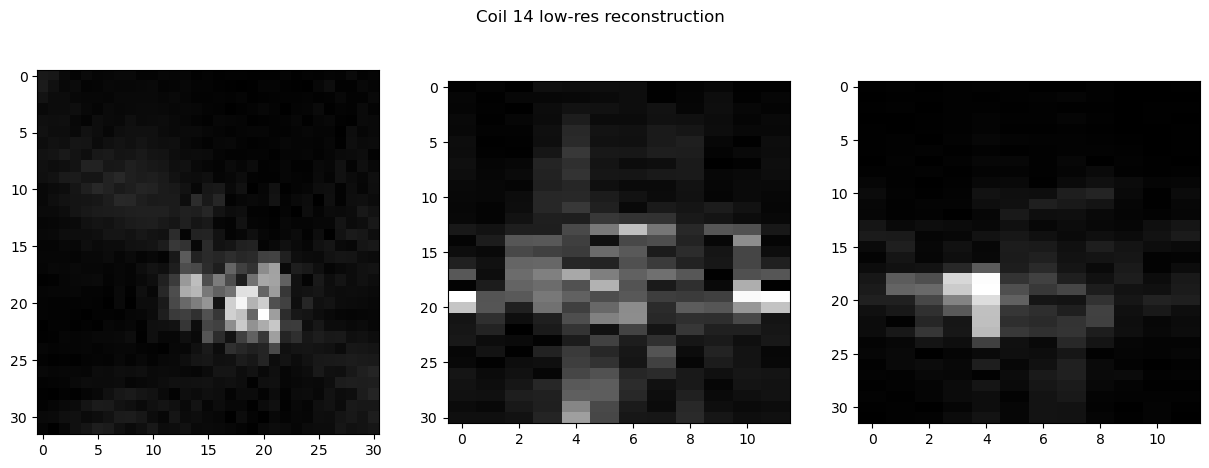

In [5]:
view_coils = [0, 8, 14]
for coil in view_coils:
    recon_plot_helpers.plot_recons_all_axes(coil_images[coil], title=f'Coil {coil} low-res reconstruction')

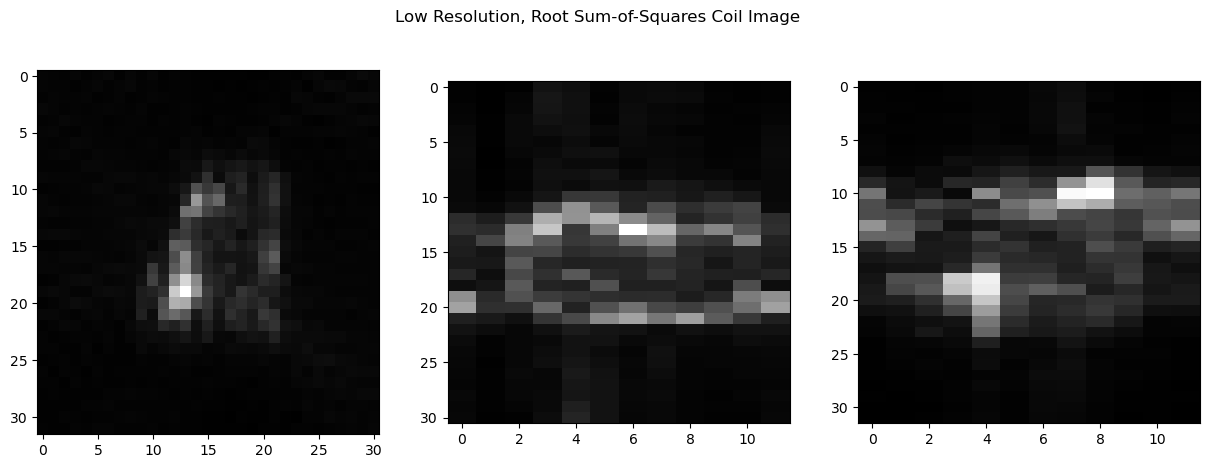

(<Figure size 1500x500 with 3 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [6]:
low_res_coil_sos = recon_plot_helpers.calculate_rss_image(coil_images, coil_axis=0)
recon_plot_helpers.plot_recons_all_axes(low_res_coil_sos, title="Low Resolution, Root Sum-of-Squares Coil Image ")

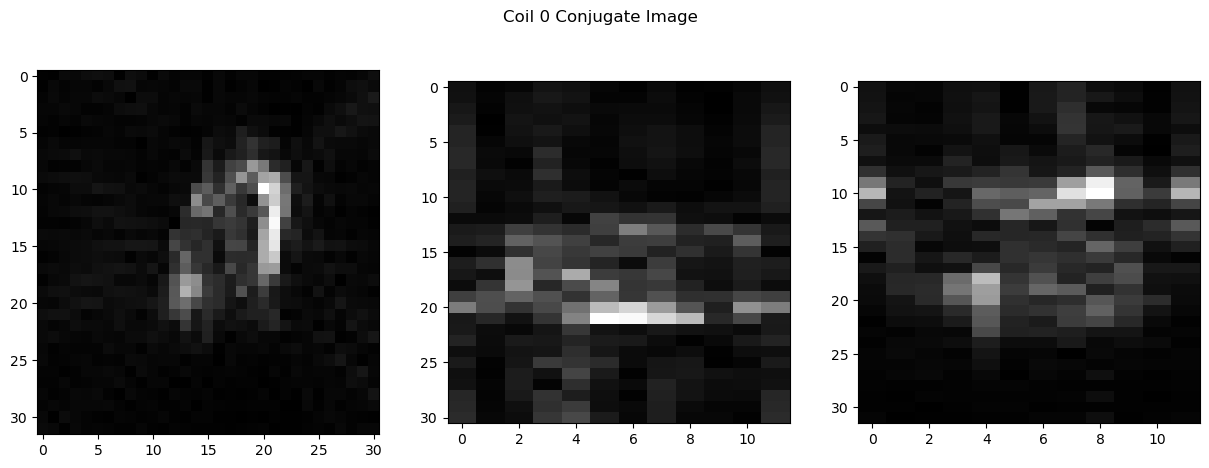

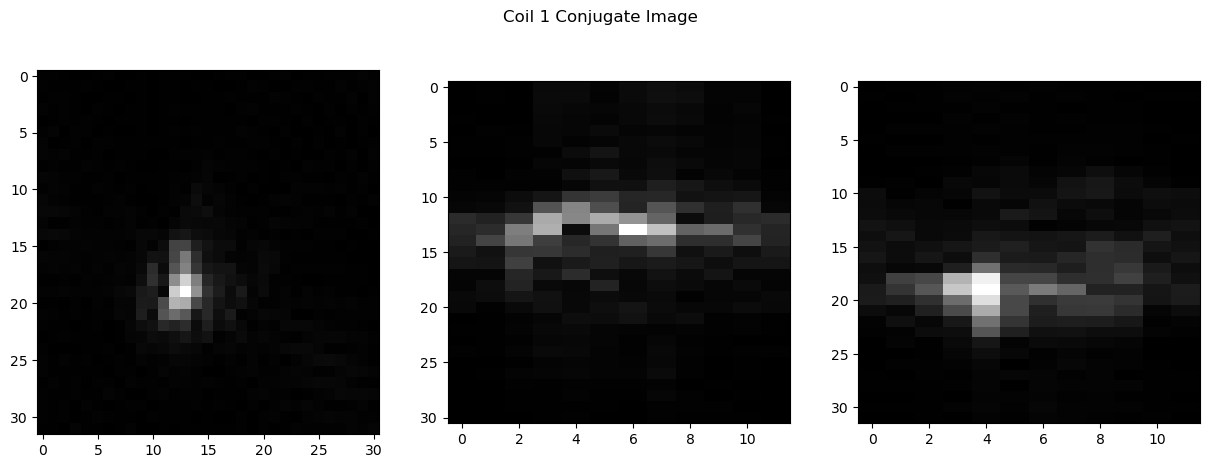

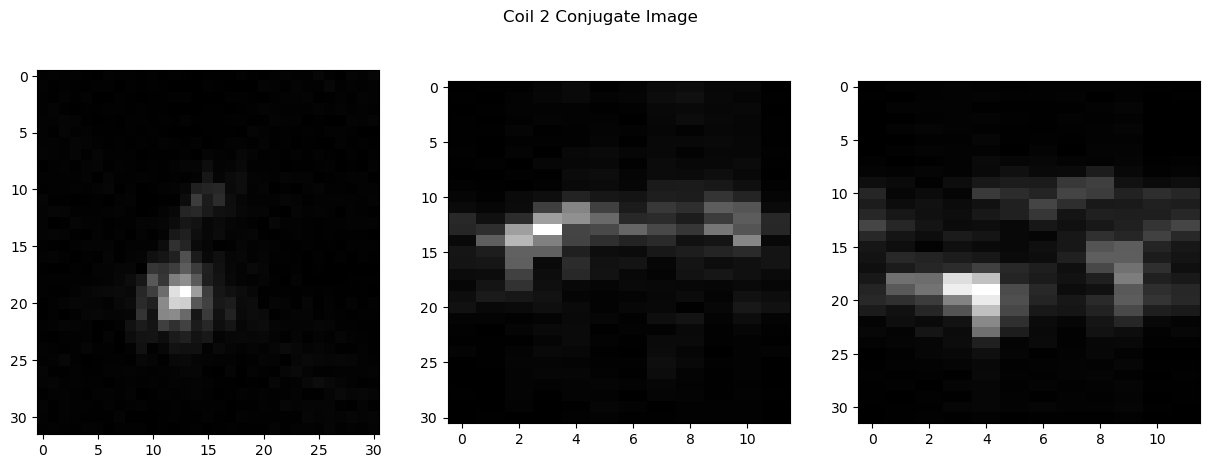

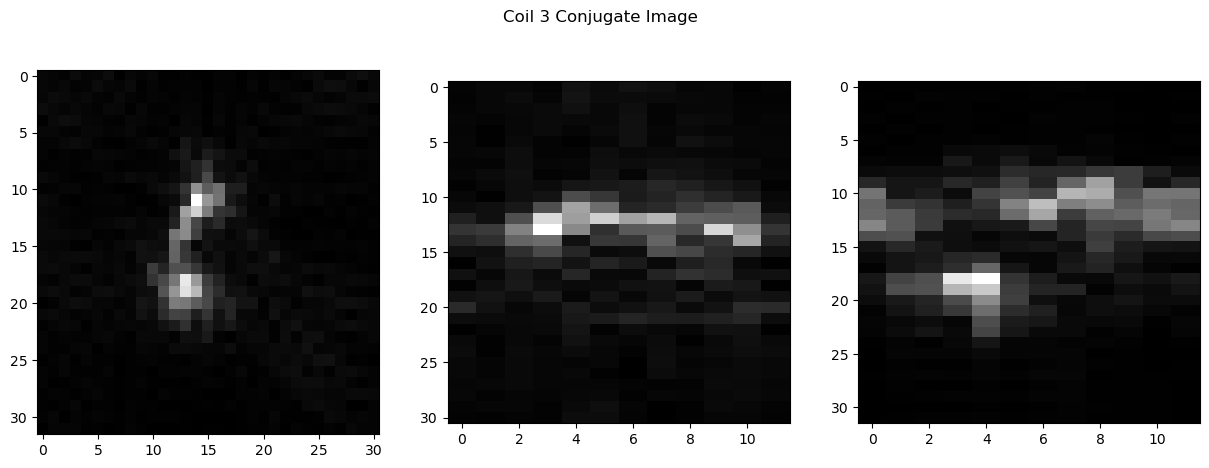

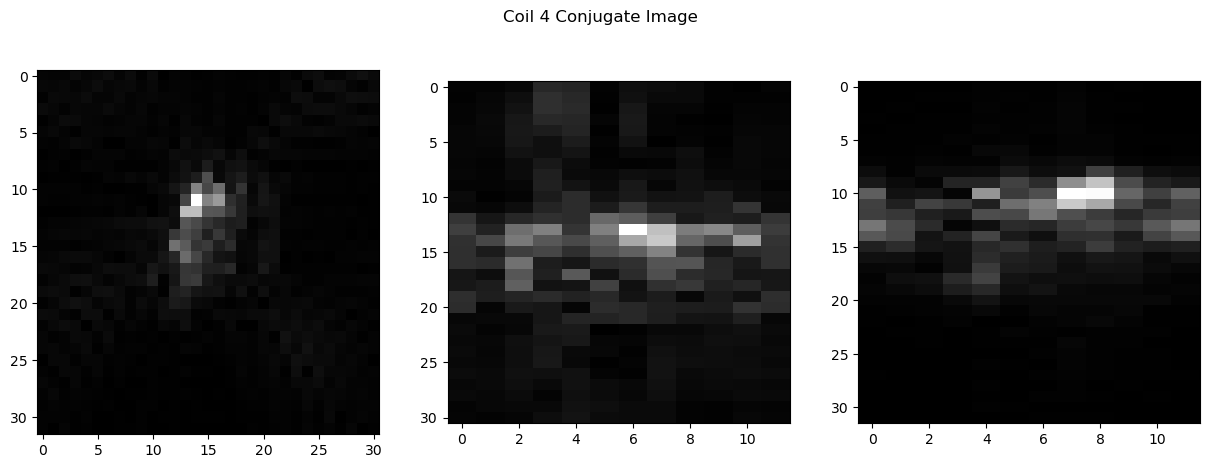

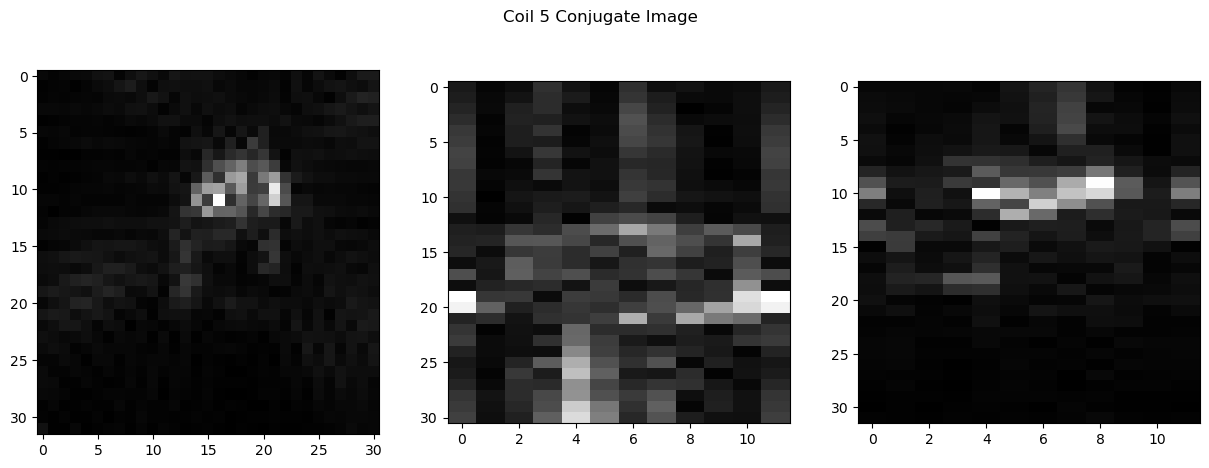

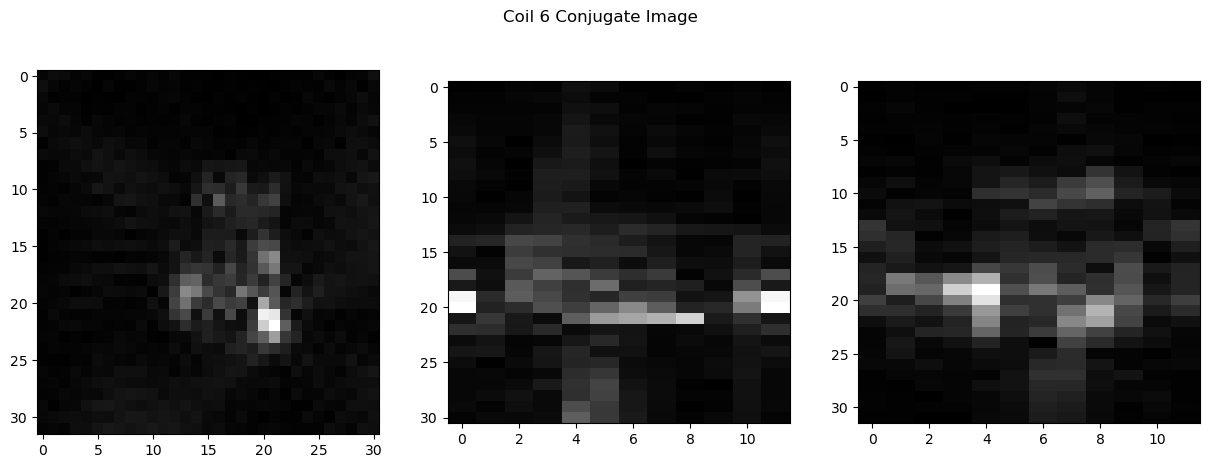

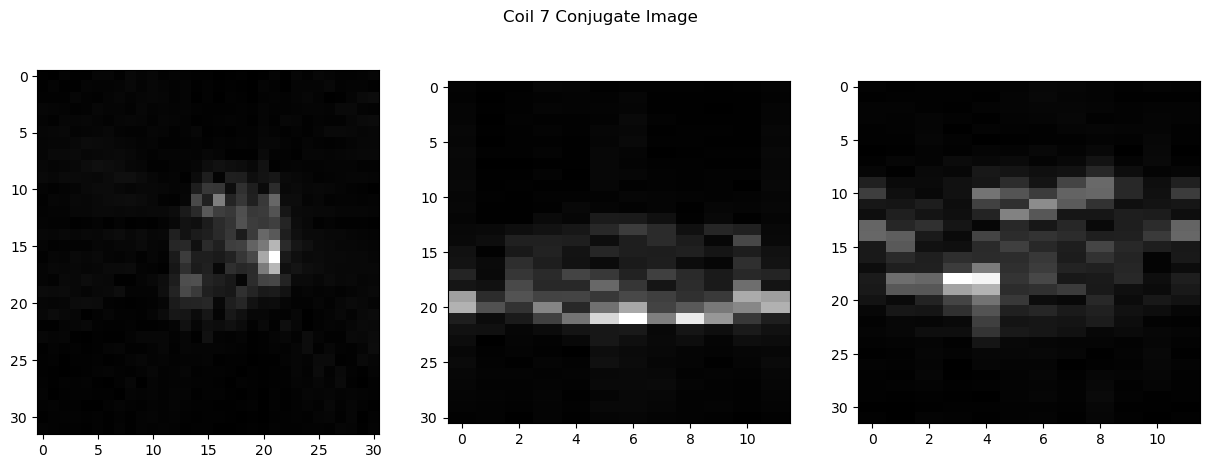

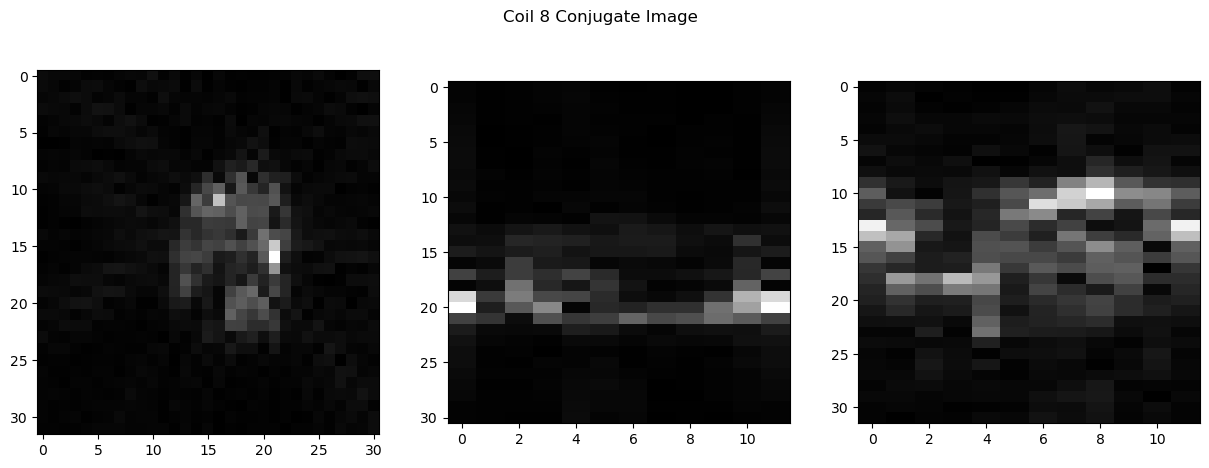

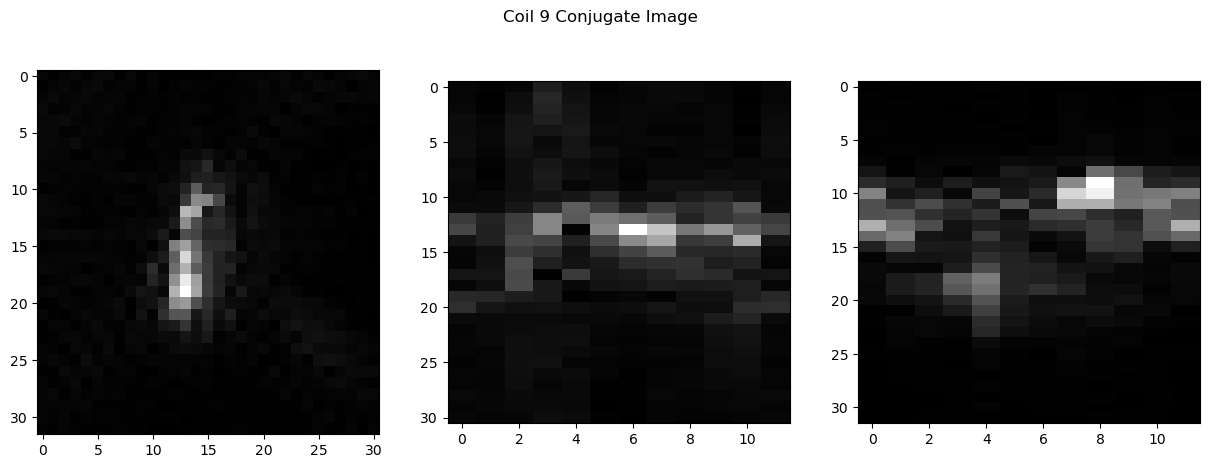

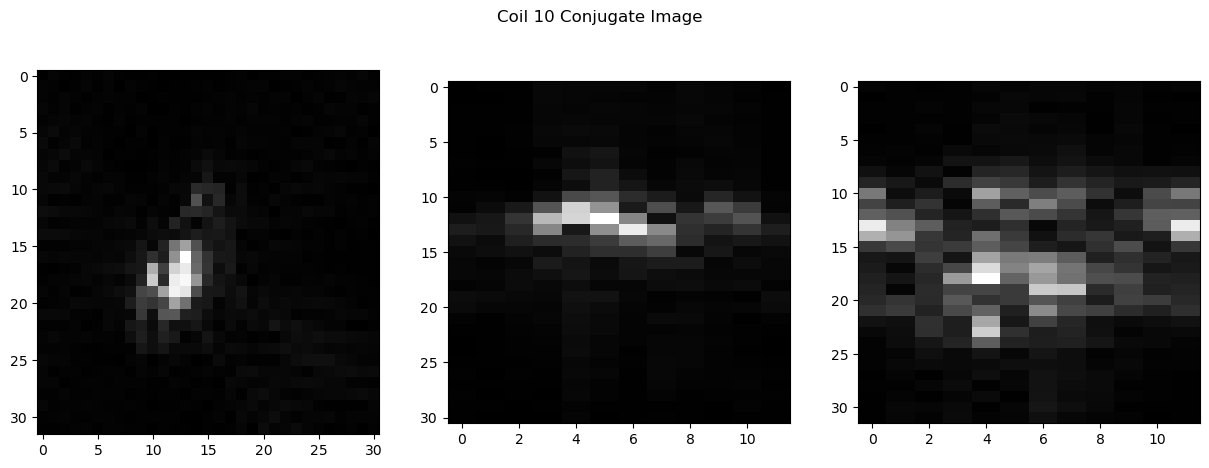

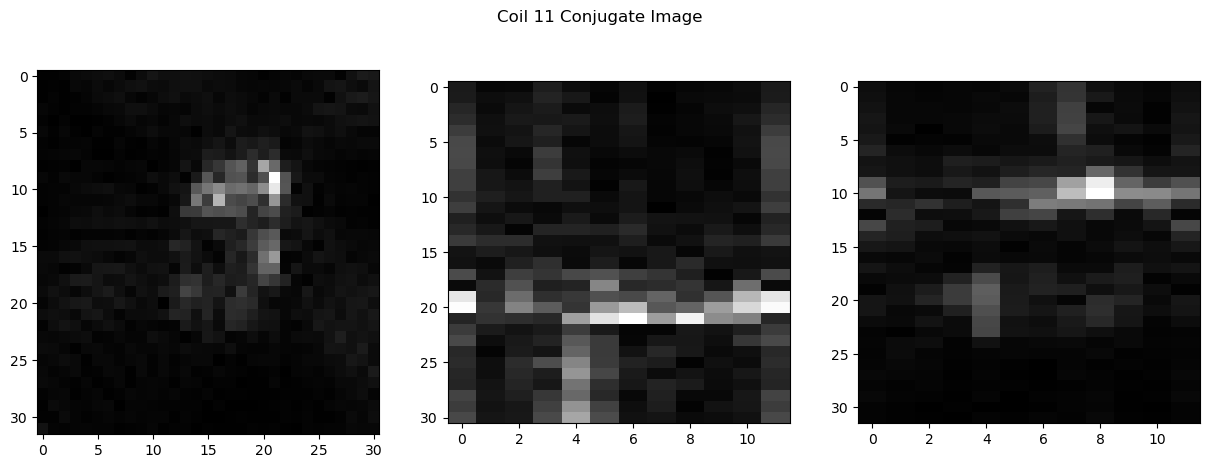

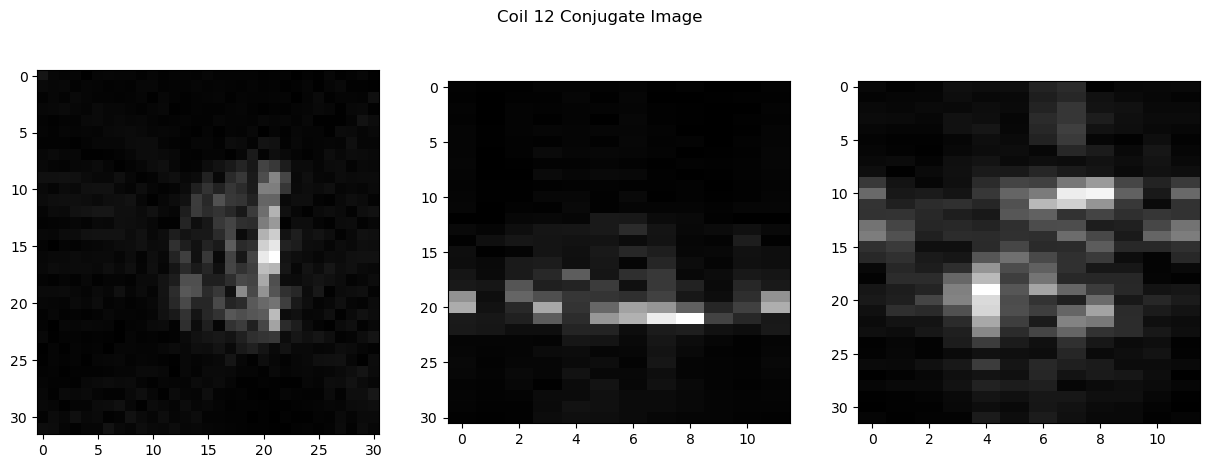

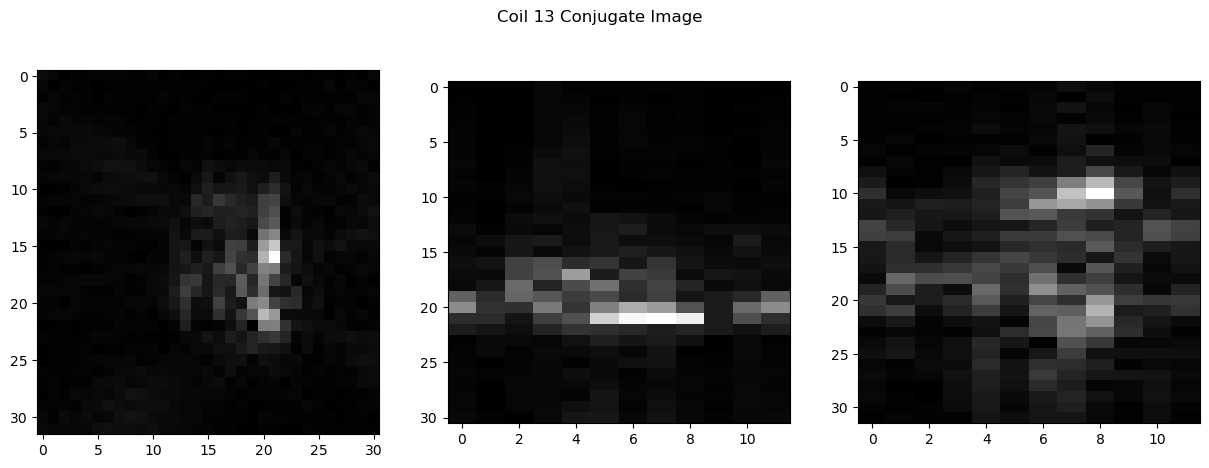

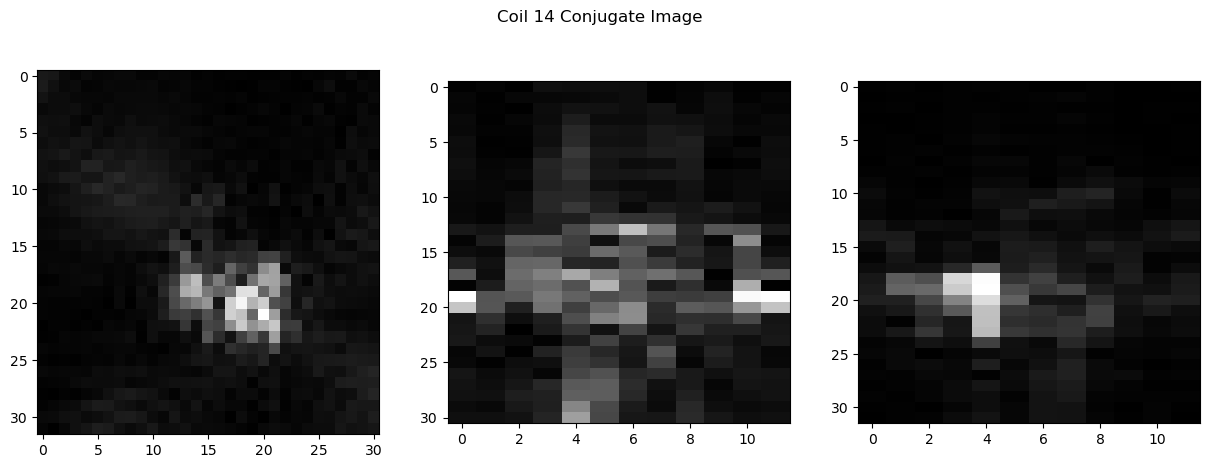

coil_images_normalized: shape = (15, 12, 32, 31), dtype=complex128
coil_images_normalized_conj: shape = (15, 12, 32, 31), dtype=complex128


In [8]:
coil_images_normalized = np.zeros(coil_images.shape, dtype=np.complex128)
coil_images_normalized_conj = np.zeros(coil_images.shape, dtype=np.complex128)
for c in range(ncoils):
    coil_images_normalized[c] = coil_images[c] / (low_res_coil_sos + 1e-10)
    coil_images_normalized_conj[c] = np.conjugate(coil_images_normalized[c])
    recon_plot_helpers.plot_recons_all_axes(coil_images_normalized_conj[c], title=f'Coil {c} Conjugate Image')

print(f'coil_images_normalized: shape = {coil_images_normalized.shape}, dtype={coil_images_normalized.dtype}')
print(f'coil_images_normalized_conj: shape = {coil_images_normalized_conj.shape}, dtype={coil_images_normalized_conj.dtype}')